# Prophet

In [1]:
import os
import pandas as pd
import numpy as np
from plt_rcs import *
import hds

In [2]:
plt.rc(group='figure', figsize=(12, 4))

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [4]:
os.chdir('../../data')

In [6]:
[i for i in os.listdir() if 'Bike' in i][0]

'Seoul_Bike_Prep.pkl'

In [7]:
objs = pd.read_pickle('Seoul_Bike_Prep.pkl')

In [8]:
globals().update(objs)

In [10]:
%whos

Variable   Type         Data/Info
---------------------------------
df         DataFrame    Shape: (1820, 1)
hds        module       <module 'hds' from '/opt/<...>ackages/hds/__init__.py'>
np         module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs       dict         n=3
os         module       <module 'os' (frozen)>
pd         module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
test       DataFrame    Shape: (365, 1)
train      DataFrame    Shape: (1461, 1)


In [11]:
df, test, train = df, test, train

## Prophet 데이터 생성

In [12]:
from prophet import Prophet

In [13]:
train.head()

,USE_CNT
RENT_DT,
2021-01-01,21873.0
2021-01-02,23185.0
2021-01-03,21410.0
2021-01-04,32436.0
2021-01-05,28598.0


In [14]:
train = train.reset_index().rename(columns={'RENT_DT': 'ds', 'USE_CNT': 'y'})

In [16]:
train.head()

,ds,y
0,2021-01-01,21873.0
1,2021-01-02,23185.0
2,2021-01-03,21410.0
3,2021-01-04,32436.0
4,2021-01-05,28598.0


In [15]:
train.dtypes

ds    datetime64[ns]
y            float64
dtype: object

## Prophet 기본 모형 적합

In [17]:
pp_basic = Prophet()

In [18]:
pp_basic.fit(train)

10:15:02 - cmdstanpy - INFO - Chain [1] start processing
10:15:03 - cmdstanpy - INFO - Chain [1] done processing


## 미래 기간 생성

In [ ]:
n_test = len(test) # 시험셋 크기 생성

In [ ]:
pp_basic_future = pp_basic.make_future_dataframe(n_test, 'D') # 시험셋 크기만큼 미래 날짜 생성

In [21]:
display(pp_basic_future.head())
display(pp_basic_future.tail())

,ds
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05


,ds
1821,2025-12-27
1822,2025-12-28
1823,2025-12-29
1824,2025-12-30
1825,2025-12-31


## Prophet 기본 모형의 예측값 생성

In [22]:
pp_basic_yhat = pp_basic.predict(pp_basic_future) # 기본 모형의 예측값 생성

In [23]:
pp_basic_yhat.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-01,74592.929847,-17798.535173,62593.983557,74592.929847,74592.929847,-50912.829792,-50912.829792,-50912.829792,10689.654342,10689.654342,10689.654342,-61602.484135,-61602.484135,-61602.484135,0.0,0.0,0.0,23680.100055
1,2021-01-02,74660.586117,-38538.575181,40538.375197,74660.586117,74660.586117,-72742.067086,-72742.067086,-72742.067086,-11234.456889,-11234.456889,-11234.456889,-61507.610197,-61507.610197,-61507.610197,0.0,0.0,0.0,1918.519031
2,2021-01-03,74728.242387,-48888.313305,34600.610724,74728.242387,74728.242387,-80767.962541,-80767.962541,-80767.962541,-19399.565965,-19399.565965,-19399.565965,-61368.396576,-61368.396576,-61368.396576,0.0,0.0,0.0,-6039.720154
3,2021-01-04,74795.898658,-20332.412540,56000.230472,74795.898658,74795.898658,-59551.077453,-59551.077453,-59551.077453,1639.355712,1639.355712,1639.355712,-61190.433165,-61190.433165,-61190.433165,0.0,0.0,0.0,15244.821205
4,2021-01-05,74863.554928,-24003.307664,57083.412808,74863.554928,74863.554928,-58039.549437,-58039.549437,-58039.549437,2939.907394,2939.907394,2939.907394,-60979.456831,-60979.456831,-60979.456831,0.0,0.0,0.0,16824.005491


In [24]:
pp_basic_pred = pp_basic_yhat.set_index('ds').loc[test.index, 'yhat'] # df를 인덱스로 설정 후 예측값만 할당

In [25]:
pp_basic_pred.head()

RENT_DT
2025-01-01    66131.347551
2025-01-02    65897.381880
2025-01-03    69200.665971
2025-01-04    47449.550835
2025-01-05    39490.450777
Name: yhat, dtype: float64

## Prophet 기본 모형의 잔차 시각화

In [ ]:
pp_basic_resid = test['USE_CNT'] - pp_basic_pred # 기본 모형 잔차 생성

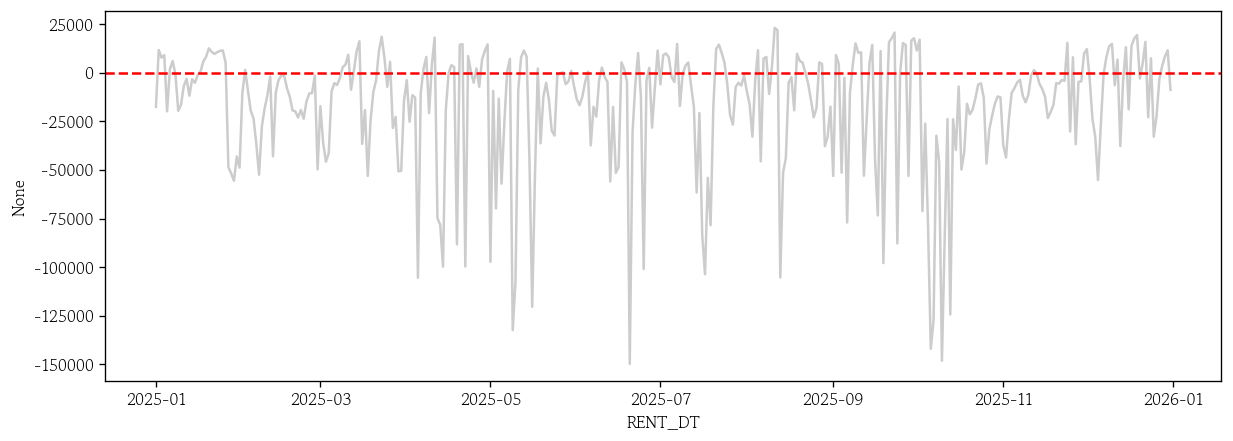

In [27]:
sns.lineplot(x=test.index, y=pp_basic_resid, color='0.8')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## Prophet 기본 모형의 잔차 자기상관 시각화

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

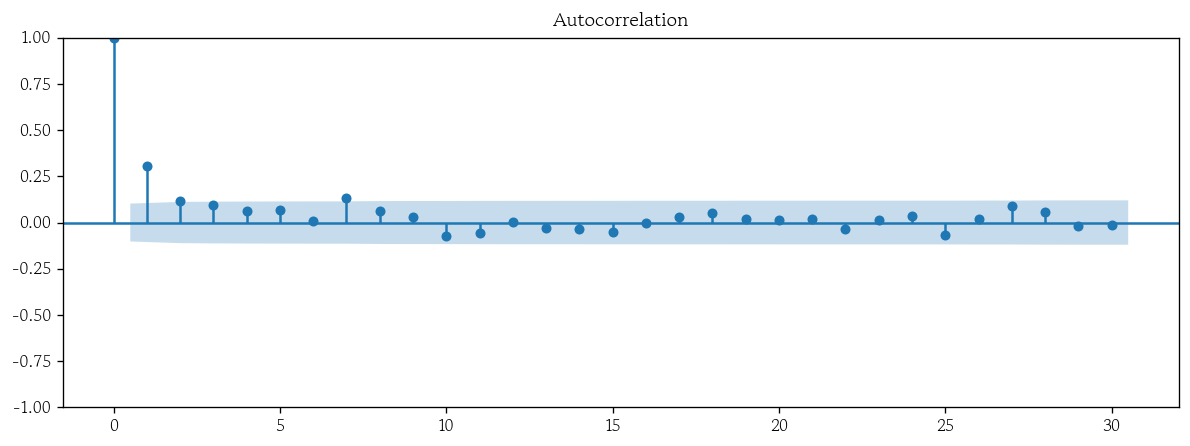

In [29]:
plot_acf(x=pp_basic_resid, lags=30);

## Prophet 기본 모형의 예측값 시각화

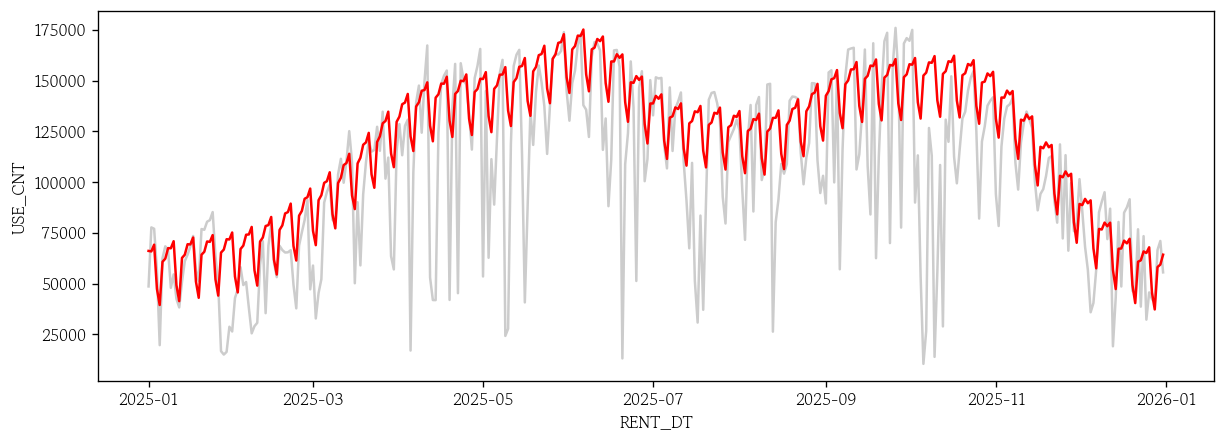

In [31]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8')
sns.lineplot(x=test.index, y=pp_basic_pred, color='red');

## Prophet 기본 모형 전체 예측 및 구성 요소 분해

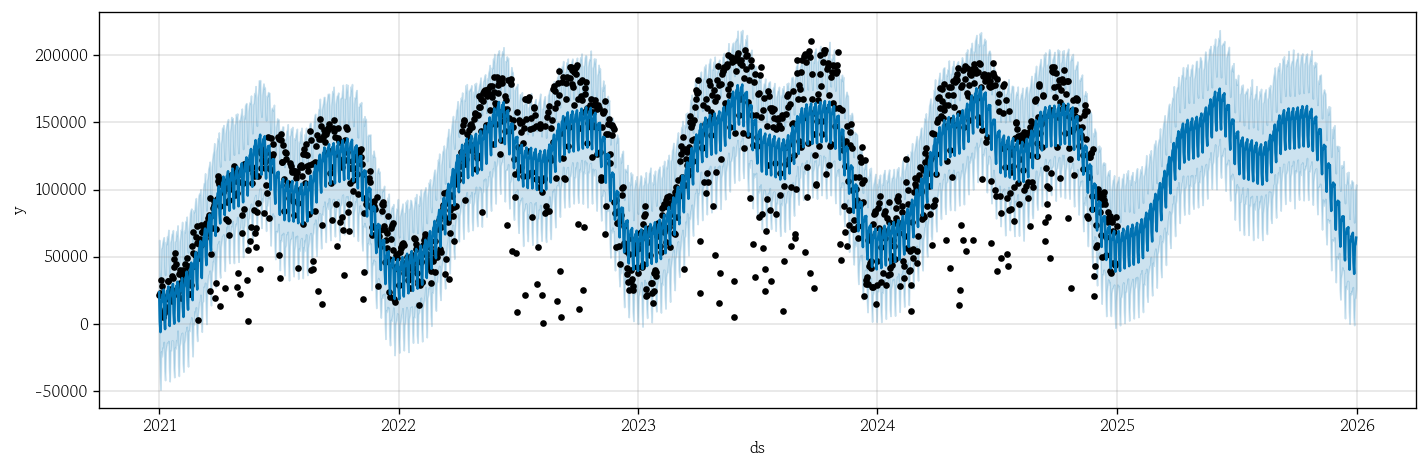

In [ ]:
pp_basic.plot(pp_basic_yhat, figsize=(12, 4)); # 기본 모형 전체 예측 시각화

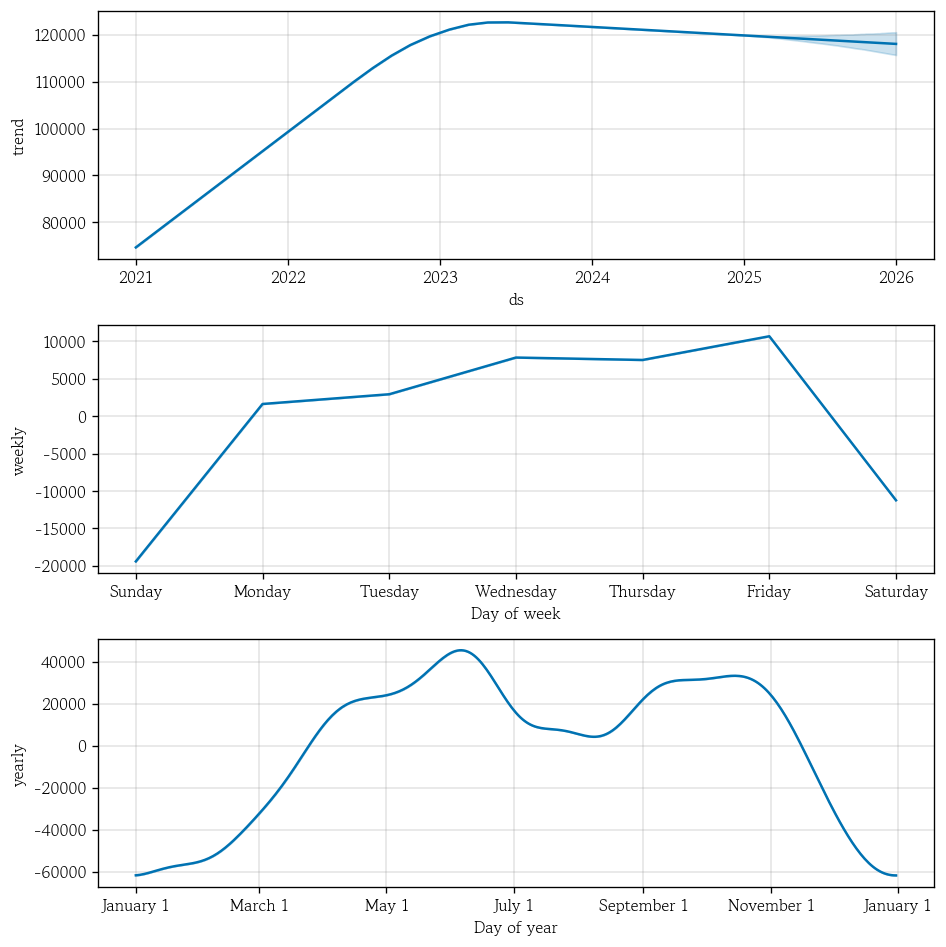

In [ ]:
pp_basic.plot_components(pp_basic_yhat, figsize=(8, 8)); # 기본 모형 구성 요소 시각화

## Prophet 기본 모형의 예측 성능 확인

In [ ]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=pp_basic_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	35219.377690
# 1	MAPE	0.483998

,metric,score
0,RMSE,35219.377690
1,MAPE,0.483998


## 외생변수 데이터셋 준비

In [41]:
[i for i in os.listdir() if 'Weather' in i]

['Seoul_Weather_Daily_2021_2025.xlsx', 'Seoul_Weather_Prep.pkl']

In [42]:
objs_exog = pd.read_pickle('Seoul_Weather_Prep.pkl')

In [43]:
globals().update(objs_exog)

In [49]:
%whos DataFrame

Variable          Type         Data/Info
----------------------------------------
df                DataFrame    Shape: (1820, 1)
exog              DataFrame    Shape: (1826, 4)
exog_test         DataFrame    Shape: (365, 4)
exog_train        DataFrame    Shape: (1461, 4)
pp_basic_future   DataFrame    Shape: (1826, 1)
pp_basic_yhat     DataFrame    Shape: (1826, 19)
test              DataFrame    Shape: (365, 1)
train             DataFrame    Shape: (1461, 2)


In [45]:
exog, exog_test, exog_train = exog, exog_test, exog_train

## Prophet 훈련셋에 외생변수 추가

In [51]:
train = pd.merge(left=train, right=exog_train, how='left', left_on='ds', right_on=exog_train.index)

In [52]:
train.head()

,ds,y,ta_max,rn_sum,hm_avg,ss_sum
0,2021-01-01,21873.0,1.4,0.0,64.916667,1558
1,2021-01-02,23185.0,-1.5,0.0,39.125000,939
2,2021-01-03,21410.0,-2.3,0.0,44.416667,1066
3,2021-01-04,32436.0,0.2,0.0,48.875000,1173
4,2021-01-05,28598.0,-2.1,0.0,54.250000,1302


## Prophet 외생변수 모형 적합

In [ ]:
pp_exog = Prophet() # 외생변수 모형 생성

In [ ]:
# 외생변수 모형에 외생변수 추가
pp_exog.add_regressor('ta_max')
pp_exog.add_regressor('rn_sum')
pp_exog.add_regressor('hm_avg')
pp_exog.add_regressor('ss_sum')

In [ ]:
pp_exog.fit(train) # 훈련셋으로 외생변수 모형 적합

11:36:54 - cmdstanpy - INFO - Chain [1] start processing
11:36:54 - cmdstanpy - INFO - Chain [1] done processing


## 미래 기간 생성

In [56]:
pp_exog_future = pp_exog.make_future_dataframe(n_test, 'D')

In [57]:
pp_exog_future.head()

,ds
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05


In [ ]:
exog = exog.reset_index().rename(columns={'date': 'ds'}) # 인덱스 초기화 후 컬럼명 통일하여 재할당

In [59]:
exog.head()

,ds,ta_max,rn_sum,hm_avg,ss_sum
0,2021-01-01,1.4,0.0,64.916667,1558
1,2021-01-02,-1.5,0.0,39.125000,939
2,2021-01-03,-2.3,0.0,44.416667,1066
3,2021-01-04,0.2,0.0,48.875000,1173
4,2021-01-05,-2.1,0.0,54.250000,1302


In [ ]:
set(pp_exog_future.columns) & set(exog.columns) # merge 이전 중복 컬럼 확인

{'ds'}

In [ ]:
pp_exog_future = pd.merge(left=pp_exog_future, right=exog, how='left') # 왼쪽 병합 후 재할당

## Prophet 외생변수 모형의 예측값 생성

In [ ]:
pp_exog_yhat = pp_exog.predict(pp_exog_future) # 외생변수 모형의 예측값 생성

In [63]:
pp_exog_yhat.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-01,74282.480689,-6144.064329,43785.691126,74282.480689,74282.480689,-54566.704794,-54566.704794,-54566.704794,-47805.196544,...,8618.801785,8618.801785,8618.801785,-15380.310035,-15380.310035,-15380.310035,0.0,0.0,0.0,19715.775895
1,2021-01-02,74338.918541,-15200.168984,33904.410530,74338.918541,74338.918541,-66208.310917,-66208.310917,-66208.310917,-38798.038330,...,-12034.581062,-12034.581062,-12034.581062,-15375.691524,-15375.691524,-15375.691524,0.0,0.0,0.0,8130.607624
2,2021-01-03,74395.356393,-31604.367348,18070.713214,74395.356393,74395.356393,-80490.387875,-80490.387875,-80490.387875,-44958.474403,...,-20159.622617,-20159.622617,-20159.622617,-15372.290856,-15372.290856,-15372.290856,0.0,0.0,0.0,-6095.031483
3,2021-01-04,74451.794245,-3770.066546,45253.004879,74451.794245,74451.794245,-53715.102895,-53715.102895,-53715.102895,-40336.695557,...,1994.919674,1994.919674,1994.919674,-15373.327012,-15373.327012,-15373.327012,0.0,0.0,0.0,20736.691350
4,2021-01-05,74508.232097,-11494.812088,37602.240977,74508.232097,74508.232097,-61476.559030,-61476.559030,-61476.559030,-51192.259871,...,5097.548445,5097.548445,5097.548445,-15381.847604,-15381.847604,-15381.847604,0.0,0.0,0.0,13031.673067


In [ ]:
pp_exog_pred = pp_exog_yhat.set_index('ds').loc[test.index, 'yhat'] # ds 인덱스 설정 후 예측값만 할당

In [ ]:
pp_exog_pred.head() 

RENT_DT
2025-01-01    80210.590047
2025-01-02    80405.206112
2025-01-03    72399.429865
2025-01-04    59860.433323
2025-01-05    11516.386895
Name: yhat, dtype: float64

## Prophet 외생변수 모형의 잔차 시각화

In [ ]:
pp_exog_resid = test['USE_CNT'] - pp_exog_pred # 외생변수 모형의 잔차 생성

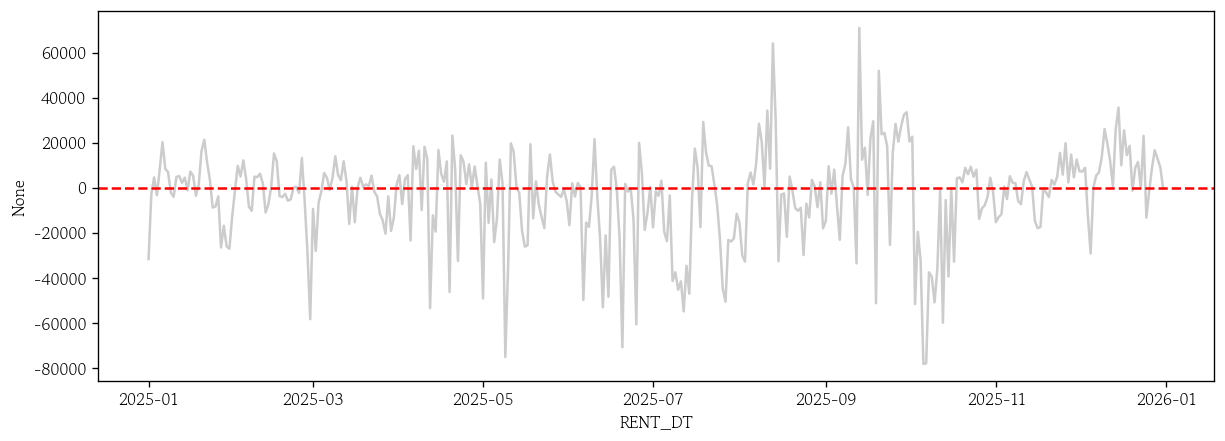

In [67]:
sns.lineplot(x=test.index, y=pp_exog_resid, color='0.8')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## Prophet 외생변수 모형의 잔차 자기상관 시각화

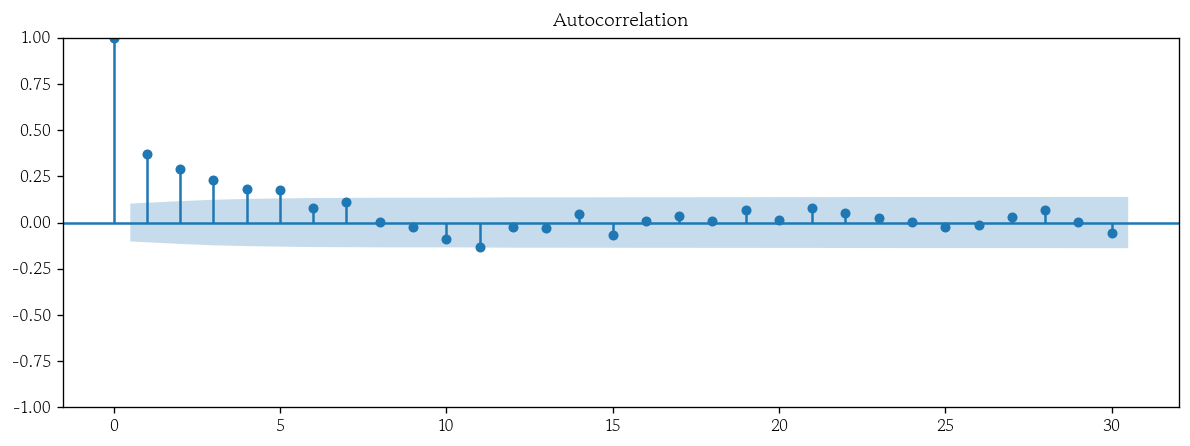

In [68]:
plot_acf(x=pp_exog_resid, lags=30);

## Prophet 외생변수 모형의 예측값 시각화

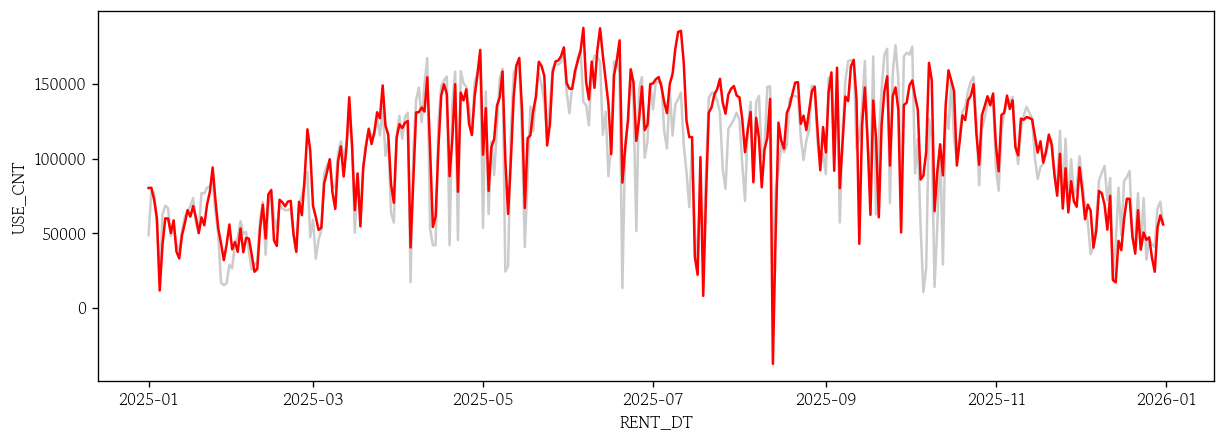

In [69]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8')
sns.lineplot(x=test.index, y=pp_exog_pred, color='red')
plt.show()

## Prophet 외생변수 모형 전체 예측 및 구성 요소 분해

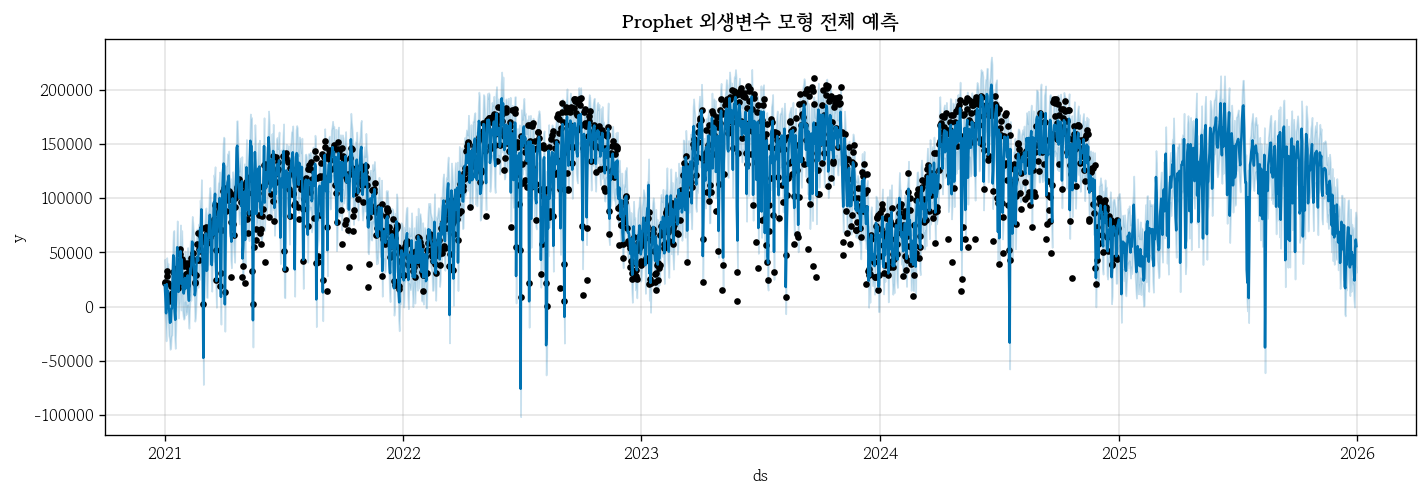

In [70]:
pp_exog.plot(pp_exog_yhat, figsize=(12, 4))
plt.title('Prophet 외생변수 모형 전체 예측', fontweight='bold');

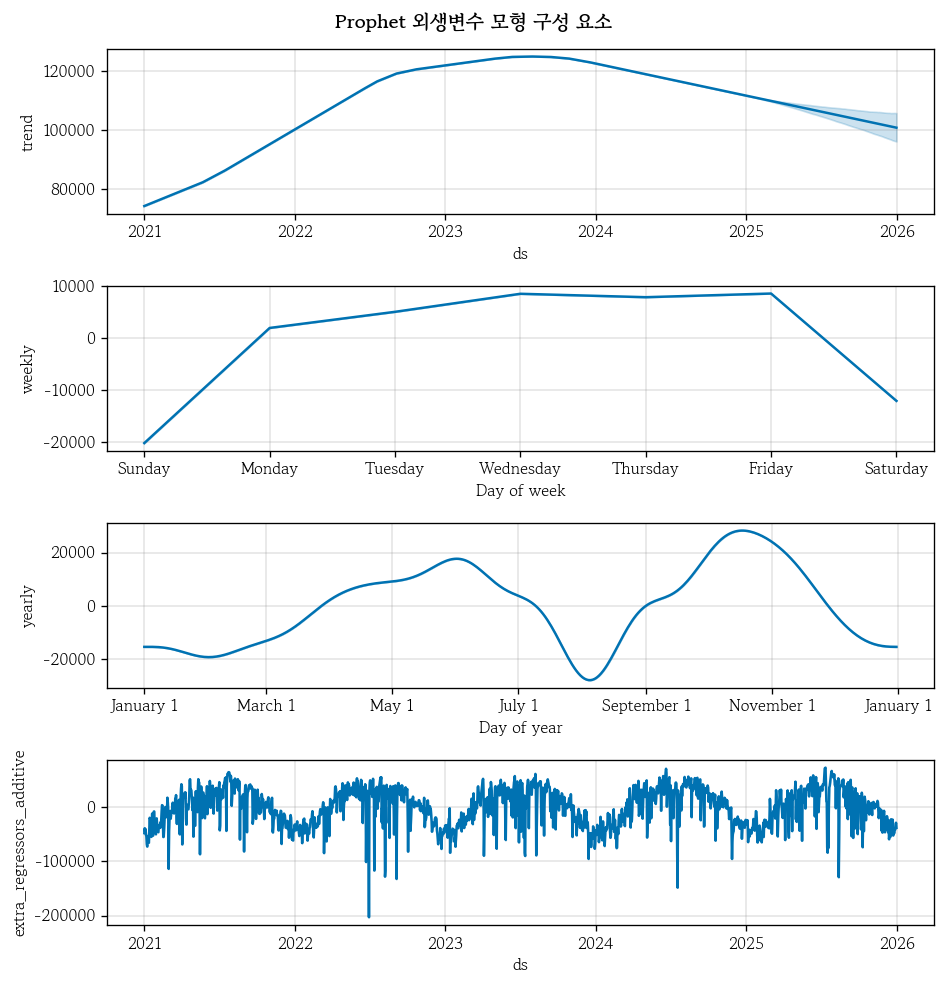

In [71]:
fig = pp_exog.plot_components(pp_exog_yhat, figsize=(8, 8))
fig.suptitle('Prophet 외생변수 모형 구성 요소', fontweight='bold', y=1.02);

## Prophet 외생변수 모형의 예측 성능 확인

In [ ]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=pp_exog_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	20827.527963
# 1	MAPE	0.247694

,metric,score
0,RMSE,20827.527963
1,MAPE,0.247694
